<h1>Activity 3 - DENGUE ANALYTICS PROJECT</h1>
<hr>
<h3>Analyst : Andrei Miguel P. Moralina</h3>
<h3>Section : BSIT - 3B</h3>

In [1]:

import pandas as pd
import numpy as np
import warnings
import seaborn as sns
import matplotlib.pyplot as plt
import folium
from folium.plugins import HeatMap
warnings.filterwarnings('ignore')

In [2]:
df = pd.read_csv('datasets\\dengue.csv')

In [3]:
df

,Month,Year,Region,Dengue_Cases,Dengue_Deaths
0,January,2016,Region I,705,1
1,February,2016,Region I,374,0
2,March,2016,Region I,276,0
3,April,2016,Region I,240,2
4,May,2016,Region I,243,1
...,...,...,...,...,...
1015,August,2020,BARMM,91,0
1016,September,2020,BARMM,16,8
1017,October,2020,BARMM,13,9
1018,November,2020,BARMM,15,1


In [5]:
df.info()
df.dtypes

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1020 entries, 0 to 1019
Data columns (total 5 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   Month          1020 non-null   object
 1   Year           1020 non-null   int64 
 2   Region         1020 non-null   object
 3   Dengue_Cases   1020 non-null   int64 
 4   Dengue_Deaths  1020 non-null   int64 
dtypes: int64(3), object(2)
memory usage: 40.0+ KB


Month            object
Year              int64
Region           object
Dengue_Cases      int64
Dengue_Deaths     int64
dtype: object

In [6]:
df.isnull().sum()

Month            0
Year             0
Region           0
Dengue_Cases     0
Dengue_Deaths    0
dtype: int64

In [14]:
month_order = ['January', 'February', 'March', 'April', 'May', 'June',
               'July', 'August', 'September', 'October', 'November', 'December']
df['Month'] = pd.Categorical(df['Month'], categories=month_order, ordered=True)

monthly_avg = df.groupby('Month')['Dengue_Cases'].mean()

<hr>
<h2>#1 DENGUE CASES TREND FROM 2016 - 2020</h2>

<Figure size 1300x800 with 0 Axes>

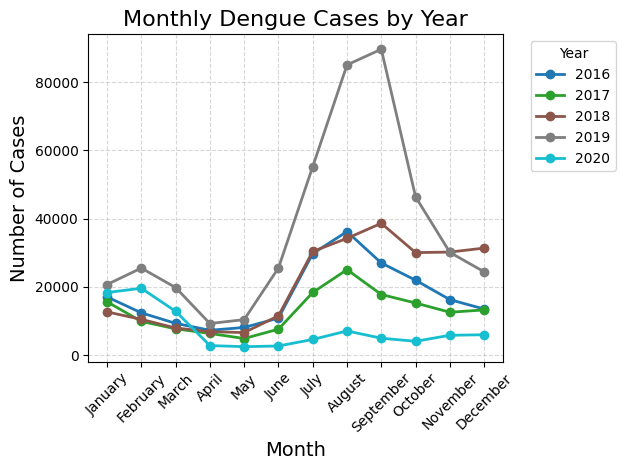

In [12]:
month_order = ['January', 'February', 'March', 'April', 'May', 'June',
               'July', 'August', 'September', 'October', 'November', 'December']

df['Month'] = pd.Categorical(df['Month'], categories=month_order, ordered=True)


monthly_cases = df.groupby(["Month", "Year"])["Dengue_Cases"].sum()
monthly_cases = monthly_cases.unstack()


plt.figure(figsize=(13, 8))
monthly_cases.plot(kind='line', marker='o', linewidth=2, cmap='tab10')

plt.title("Monthly Dengue Cases by Year", fontsize=16)
plt.xlabel("Month", fontsize=14)
plt.ylabel("Number of Cases", fontsize=14)

plt.grid(True, linestyle='--', alpha=0.5)
plt.xticks(range(0, 12), month_order, rotation=45)


plt.legend(title="Year", bbox_to_anchor=(1.05, 1), loc='upper left')

plt.tight_layout()
plt.show()


<h2>Insight No.1</h2>
<h3>This visualization presents the monthly distribution of dengue cases across different years. By examining the trends month-by-month, we can observe recurring seasonal patterns that may be linked to environmental factors such as rainfall, temperature, and mosquito breeding cycles. Months showing consistently higher case counts may indicate periods when dengue transmission risk is elevated. This information is valuable for public health planning, enabling authorities to anticipate outbreak peaks, strengthen preventive measures, and allocate healthcare resources more effectively.</h3>
<hr>

<h2>2. Monthly Trends in Dengue Cases Across Years</h2>

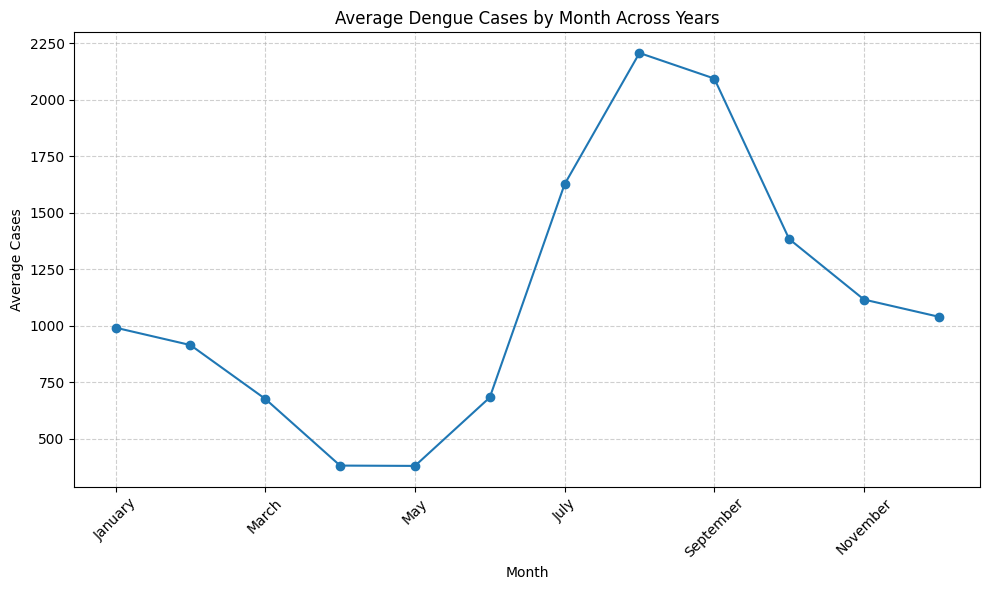

In [15]:
monthly_avg.plot(kind='line', marker='o', figsize=(10, 6))

plt.title('Average Dengue Cases by Month Across Years')
plt.ylabel('Average Cases')
plt.xlabel('Month')
plt.xticks(rotation=45)

plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

<h2>Insight No.2</h2>
<h3>The plot shows how dengue cases fluctuate throughout the year. A clear seasonal trend emerges, with cases rising sharply around mid-year and typically peaking in July. These increases often align with environmental conditions such as higher rainfall and humidity, which support mosquito breeding. Meanwhile, months like January to March and September to November consistently show lower case numbers, indicating a period of reduced dengue transmission. Recognizing these patterns is crucial for planning timely interventions and optimizing public health resources.</h3>
<hr>

<h2>3. Correlation Between Cases and Deaths</h2>

Correlation coefficient: 0.03832213720419488


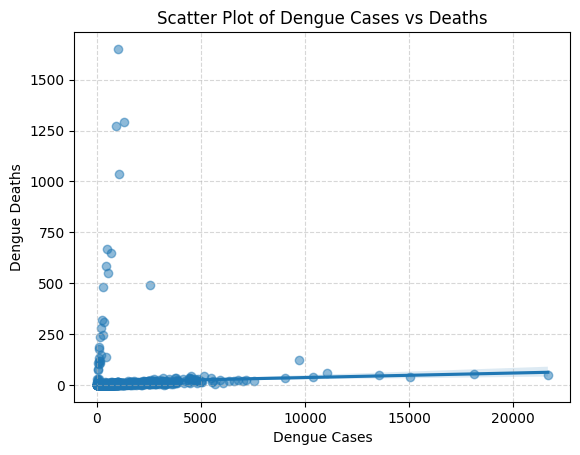

In [16]:
correlation = df['Dengue_Cases'].corr(df['Dengue_Deaths'])
print(f"Correlation coefficient: {correlation}")

sns.regplot(x='Dengue_Cases', y='Dengue_Deaths', data=df, scatter_kws={'alpha':0.5})
plt.title('Scatter Plot of Dengue Cases vs Deaths')
plt.xlabel('Dengue Cases')
plt.ylabel('Dengue Deaths')
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

<h2>Insight No.3</h2>
<h3>This analysis examines the relationship between the number of dengue cases and resulting deaths. The computed correlation coefficient indicates only a weak positive relationship, meaning increases in dengue cases do not consistently correspond to higher death counts. The scatter plot reinforces this observation, showing that the majority of data points cluster at lower case and death values. This suggests that although cases may rise significantly, fatalities remain relatively low—possibly due to effective clinical management, timely treatment, or early detection efforts. Understanding this weak association helps contextualize disease severity and guides public health decision-making.</h3>
<hr>

<h2>4. Comparison of 2019 vs 2020 Cases</h2>

2019: 441902, 2020: 91041, Change: -79.40%


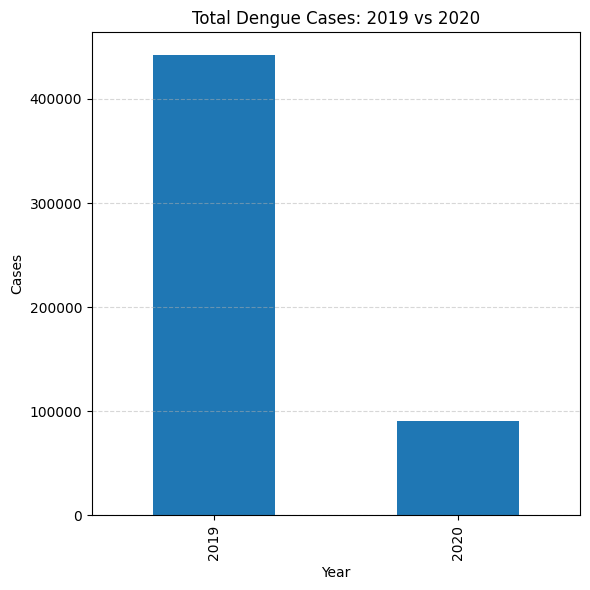

In [17]:
cases_2019 = df[df['Year'] == 2019]['Dengue_Cases'].sum()
cases_2020 = df[df['Year'] == 2020]['Dengue_Cases'].sum()

change_percent = ((cases_2020 - cases_2019) / cases_2019) * 100
print(f"2019: {cases_2019}, 2020: {cases_2020}, Change: {change_percent:.2f}%")

pd.Series({'2019': cases_2019, '2020': cases_2020}).plot(kind='bar', figsize=(6, 6))

plt.title('Total Dengue Cases: 2019 vs 2020')
plt.ylabel('Cases')
plt.xlabel('Year')
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

<h2>Insight No.4</h2>
<h3>The bar chart compares the total dengue cases reported in 2019 and 2020, revealing a substantial decline in incidence. In 2019, recorded cases were significantly higher, while 2020 experienced a sharp reduction, amounting to an approximate decrease of nearly 80%. This dramatic shift may reflect multiple factors, including enhanced public health measures, changes in population mobility during the COVID-19 pandemic, improved vector control strategies, or variations in environmental conditions that affect mosquito breeding. The contrast underscores how external circumstances can greatly influence dengue transmission dynamics.</h3>
<hr>

<h2>5. Impact of Outbreaks: 2019 Spike Analysis</h2>

2019 Cases: 441902, Avg Other Years: 176380.75, Excess: 265521.25


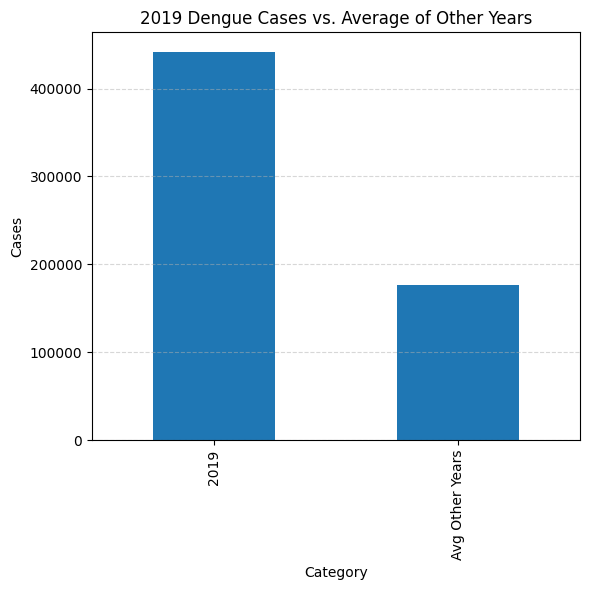

In [18]:
cases_2019 = df[df['Year'] == 2019]['Dengue_Cases'].sum()

avg_other_years = df[df['Year'] != 2019].groupby('Year')['Dengue_Cases'].sum().mean()

print(f"2019 Cases: {cases_2019}, Avg Other Years: {avg_other_years}, Excess: {cases_2019 - avg_other_years}")

pd.Series({'2019': cases_2019, 'Avg Other Years': avg_other_years}).plot(kind='bar', figsize=(6, 6))

plt.title('2019 Dengue Cases vs. Average of Other Years')
plt.ylabel('Cases')
plt.xlabel('Category')
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

<h2>Insight No.5</h2>
<h3>This comparison highlights the extraordinary surge in dengue cases recorded in 2019. The total number of cases that year far exceeded the average case count from other years, indicating an unusual and severe outbreak. With 2019 showing more than double the average incidence, the spike suggests the presence of significant epidemiological factors such as intensified mosquito breeding, optimal climatic conditions, lapses in vector control, or viral strain variations. Such deviations from the norm highlight the importance of monitoring environmental and public health indicators to anticipate and prevent future outbreaks of similar scale.</h3>
<hr>

<h2>6. Proportion of Deaths by Year</h2>

Year
2016    8127
2017    4563
2018    1226
2019    1733
2020    1195
Name: Dengue_Deaths, dtype: int64


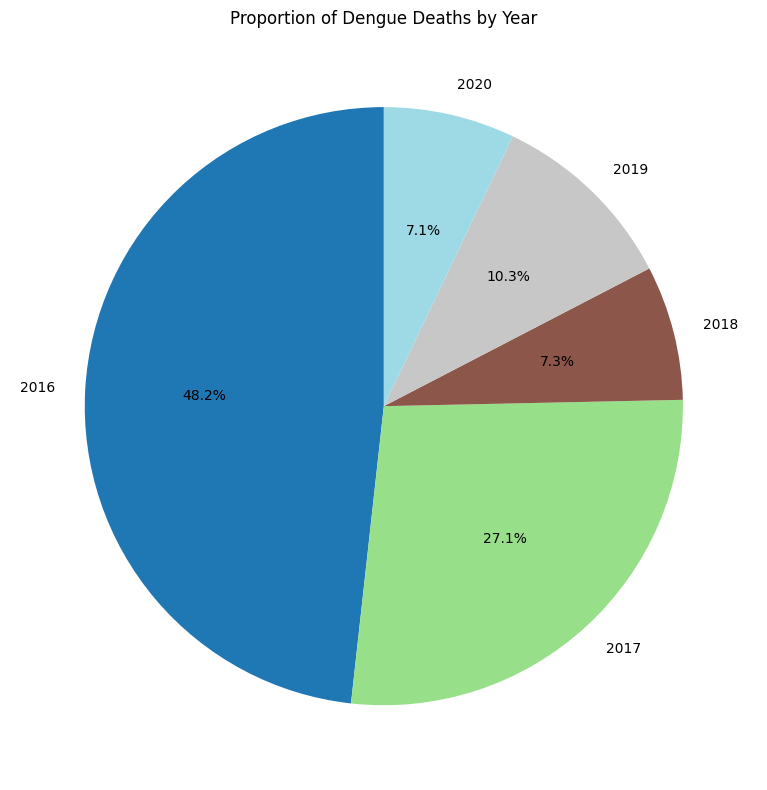

In [19]:
yearly_deaths = df.groupby('Year')['Dengue_Deaths'].sum()
print(yearly_deaths)

yearly_deaths.plot(kind='pie', autopct='%1.1f%%', figsize=(8, 8), startangle=90, cmap='tab20')
plt.title('Proportion of Dengue Deaths by Year')
plt.ylabel('')
plt.tight_layout()
plt.show()

<h2>Insight No.6</h2>
<h3>The pie chart illustrates the distribution of dengue-related deaths from 2016 to 2020. Among these years, 2016 accounts for nearly half of all deaths, indicating it was the most severely affected year. This visualization provides a clear comparative perspective, allowing public health authorities to identify years with higher mortality and investigate potential contributing factors, such as outbreak severity, healthcare response, or environmental conditions. Understanding these trends is crucial for future preparedness and targeted interventions.</h3>
<hr>

<h2>7. Scatter Plot of Cases vs. Deaths with Region Size</h2>

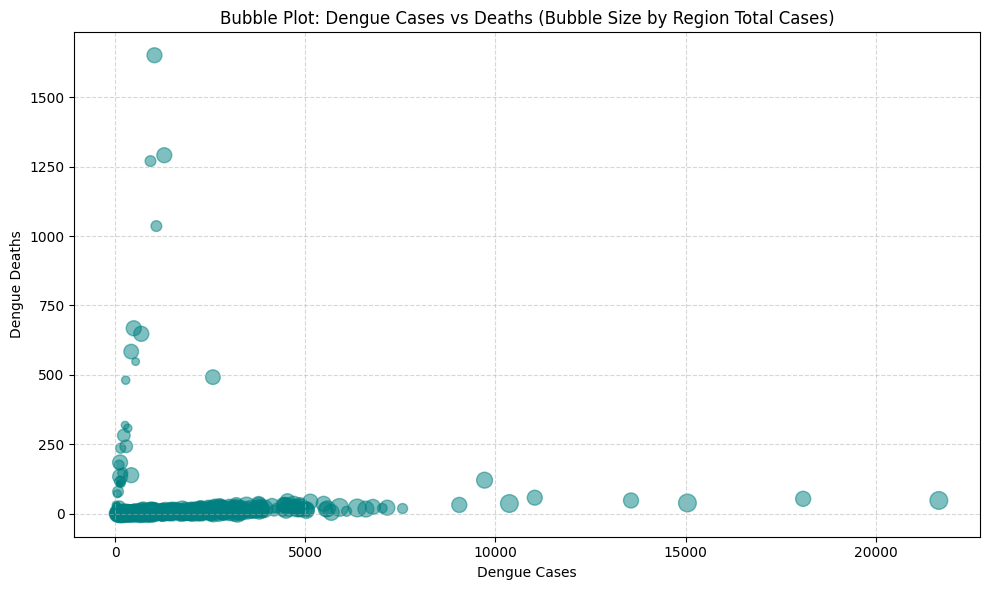

In [20]:
region_size = df.groupby('Region')['Dengue_Cases'].sum()
df['Region_Size'] = df['Region'].map(region_size)

plt.figure(figsize=(10, 6))
plt.scatter(df['Dengue_Cases'], df['Dengue_Deaths'], s=df['Region_Size']/1000, alpha=0.5, color='teal')
plt.title('Bubble Plot: Dengue Cases vs Deaths (Bubble Size by Region Total Cases)')
plt.xlabel('Dengue Cases')
plt.ylabel('Dengue Deaths')
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

<h2>Insight No.7</h2>
<h3>The bubble plot visualizes the relationship between dengue cases and deaths across different regions, with bubble size proportional to the total number of cases in each region. Most data points cluster at lower values of cases and deaths, reflecting regions with relatively mild outbreaks. However, a few bubbles appear higher on the death scale, indicating areas with disproportionately high mortality despite case counts. This visualization helps identify regions with high-risk outbreaks, enabling targeted public health interventions and resource allocation. It also provides a nuanced view of the correlation between case burden and fatalities across regions.</h3>
<hr>

<h2>8. Which region has the highest total dengue cases?</h2>

Region with highest cases: Region IV-A (163029 cases)


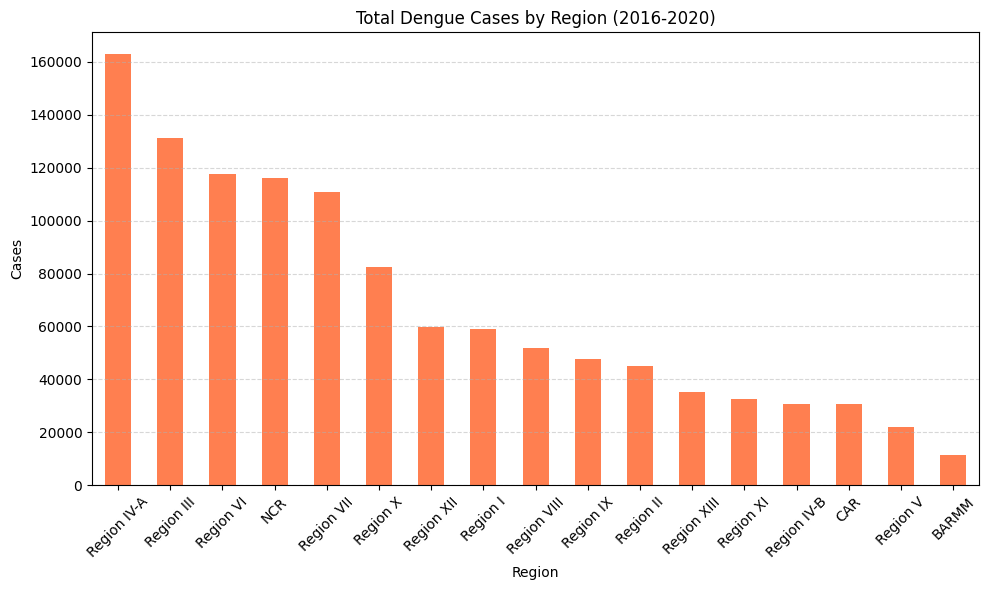

In [21]:
region_cases = df.groupby('Region')['Dengue_Cases'].sum().sort_values(ascending=False)
top_region = region_cases.idxmax()
print(f"Region with highest cases: {top_region} ({region_cases.max()} cases)")

region_cases.plot(kind='bar', figsize=(10, 6), color='coral')
plt.title('Total Dengue Cases by Region (2016-2020)')
plt.ylabel('Cases')
plt.xlabel('Region')
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

<h2>Insight No.8</h2>
<h3>The bar chart highlights the total dengue cases across regions over the five-year period. Region IV-A emerges as the most affected, recording the highest total cases at 163,029. Other regions, such as Region III and Region VI, also report significant cases but are substantially lower than Region IV-A. This visualization provides a clear comparison of dengue burden across regions, helping public health officials prioritize interventions, allocate resources efficiently, and identify areas requiring intensified vector control and monitoring.</h3>
<hr>

<h2>9. What are the average dengue cases by month across all years?</h2>

Month
January       992.094118
February      915.305882
March         677.364706
April         382.447059
May           381.023529
June          683.647059
July         1626.376471
August       2206.517647
September    2093.447059
October      1384.058824
November     1116.470588
December     1040.364706
Name: Dengue_Cases, dtype: float64


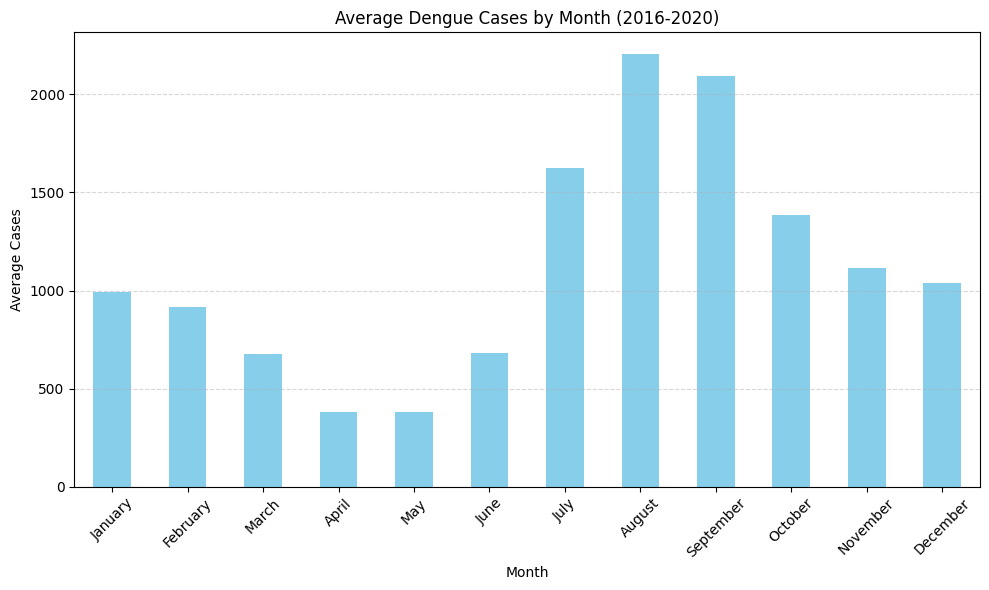

In [22]:
avg_monthly = df.groupby('Month')['Dengue_Cases'].mean()
print(avg_monthly)

avg_monthly.plot(kind='bar', figsize=(10, 6), color='skyblue')
plt.title('Average Dengue Cases by Month (2016-2020)')
plt.ylabel('Average Cases')
plt.xlabel('Month')
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

<h2>Insight No.9</h2>
<h3>The bar chart shows the average dengue cases for each month over the five-year period. Peak cases occur in July and August, reflecting a clear seasonal trend likely linked to increased rainfall and favorable conditions for mosquito breeding. In contrast, January consistently shows the lowest average cases, indicating a lull in transmission. Understanding these seasonal patterns is essential for planning targeted public health interventions, deploying resources effectively, and implementing preventive measures during high-risk months.</h3>
<hr>

<h2>10. Compare cases in rainy season (June-Oct) vs dry season (Nov-May).</h2>

Rainy Season Cases: 679494, Dry Season Cases: 467931


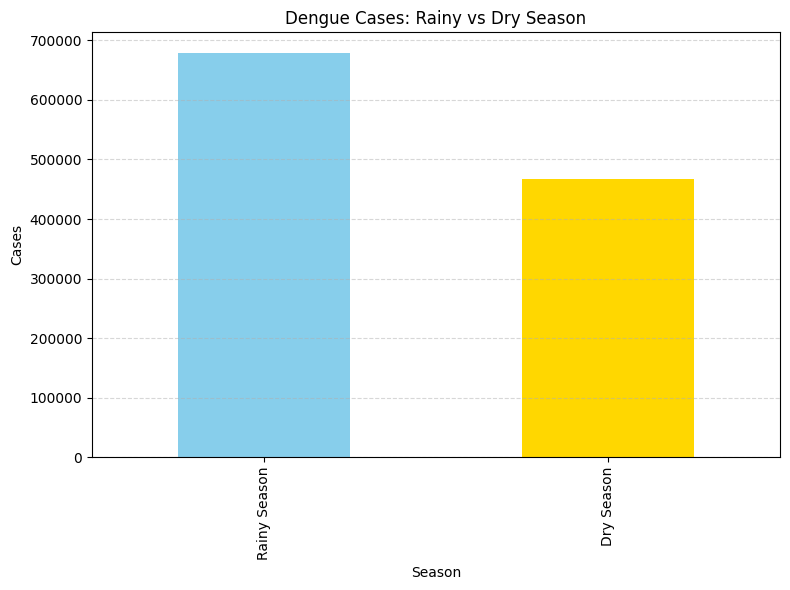

In [25]:
rainy_months = ['June', 'July', 'August', 'September', 'October']
dry_months = ['November', 'December', 'January', 'February', 'March', 'April', 'May']

rainy_cases = df[df['Month'].isin(rainy_months)]['Dengue_Cases'].sum()
dry_cases = df[df['Month'].isin(dry_months)]['Dengue_Cases'].sum()

print(f"Rainy Season Cases: {rainy_cases}, Dry Season Cases: {dry_cases}")

pd.Series({'Rainy Season': rainy_cases, 'Dry Season': dry_cases}).plot(kind='bar', figsize=(8,6), color=['skyblue','gold'])
plt.title('Dengue Cases: Rainy vs Dry Season')
plt.ylabel('Cases')
plt.xlabel('Season')
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

<h2>Insight No.10</h2>
<h3>The bar chart shows that dengue cases are markedly higher during the rainy season, with 679,494 cases, compared to 467,931 cases in the dry season. This indicates that seasonal weather patterns, such as increased rainfall and humidity during the rainy months, significantly influence mosquito breeding and dengue transmission. Recognizing these seasonal trends helps public health authorities plan timely vector control measures, intensify awareness campaigns, and allocate resources efficiently to reduce the risk of outbreaks during high-transmission periods.</h3>